# 🌿 Potato Leaf Disease Classifier
### EfficientNetB4 Transfer Learning — PlantVillage Dataset

## Cell 1 — Install Dependencies

In [1]:
!pip install split-folders tensorflow matplotlib pillow


## Cell 2 — Imports

In [2]:
import os
import shutil
import splitfolders
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


## Cell 3 — Paths (Update if needed)

In [3]:
import os

# Base project directory — update this to your actual path
BASE_DIR    = r'C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor'

RAW_DATA_DIR = os.path.join(BASE_DIR, 'raw_data')
DATASET_DIR  = os.path.join(BASE_DIR, 'dataset')
TRAIN_DIR    = os.path.join(DATASET_DIR, 'train')
VAL_DIR      = os.path.join(DATASET_DIR, 'val')
TEST_DIR     = os.path.join(DATASET_DIR, 'test')
MODEL_PATH   = os.path.join(BASE_DIR, 'plant_disease_model.keras')

print('BASE_DIR    :', BASE_DIR)
print('RAW_DATA_DIR:', RAW_DATA_DIR)
print('DATASET_DIR :', DATASET_DIR)
print('MODEL_PATH  :', MODEL_PATH)

# Verify raw_data exists and has the 3 potato folders
assert os.path.exists(RAW_DATA_DIR), f'raw_data not found at {RAW_DATA_DIR}'
classes = os.listdir(RAW_DATA_DIR)
print('\nClasses in raw_data:', classes)
assert len(classes) == 3, 'Expected exactly 3 Potato class folders in raw_data'
print('\n✅ raw_data looks correct!')


BASE_DIR    : C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor
RAW_DATA_DIR: C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor\raw_data
DATASET_DIR : C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor\dataset
MODEL_PATH  : C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor\plant_disease_model.keras

Classes in raw_data: ['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']

✅ raw_data looks correct!


## Cell 4 — Split Dataset (Skip if dataset/ already exists)

In [4]:
import splitfolders

# Only split if train folder doesn't already exist
if not os.path.exists(TRAIN_DIR):
    print('Splitting dataset 80% train / 10% val / 10% test ...')
    splitfolders.ratio(
        RAW_DATA_DIR,
        output = DATASET_DIR,
        seed   = 1337,
        ratio  = (0.8, 0.1, 0.1)
    )
    print('\n✅ Split complete!')
else:
    print('✅ dataset/train already exists — skipping split.')

# Print count per split
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATASET_DIR, split)
    total = 0
    for cls in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, cls)))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  → {split} total: {total}\n')


✅ dataset/train already exists — skipping split.
  train/Potato___Early_blight: 1551 images
  train/Potato___healthy: 1459 images
  train/Potato___Late_blight: 1551 images
  → train total: 4561

  val/Potato___Early_blight: 193 images
  val/Potato___healthy: 182 images
  val/Potato___Late_blight: 193 images
  → val total: 568

  test/Potato___Early_blight: 195 images
  test/Potato___healthy: 183 images
  test/Potato___Late_blight: 195 images
  → test total: 573



## Cell 5 — Load Datasets

In [5]:
BATCH_SIZE = 32
IMG_SIZE   = (160, 160)
AUTOTUNE   = tf.data.AUTOTUNE

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle    = True,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    shuffle    = True,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle    = False,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE
)

class_names = train_dataset.class_names
print(f'Total classes : {len(class_names)}')
print(f'Class names   : {class_names}')


Found 4561 files belonging to 3 classes.
Found 568 files belonging to 3 classes.
Found 573 files belonging to 3 classes.
Total classes : 3
Class names   : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## Cell 6 — Visualise Sample Training Images

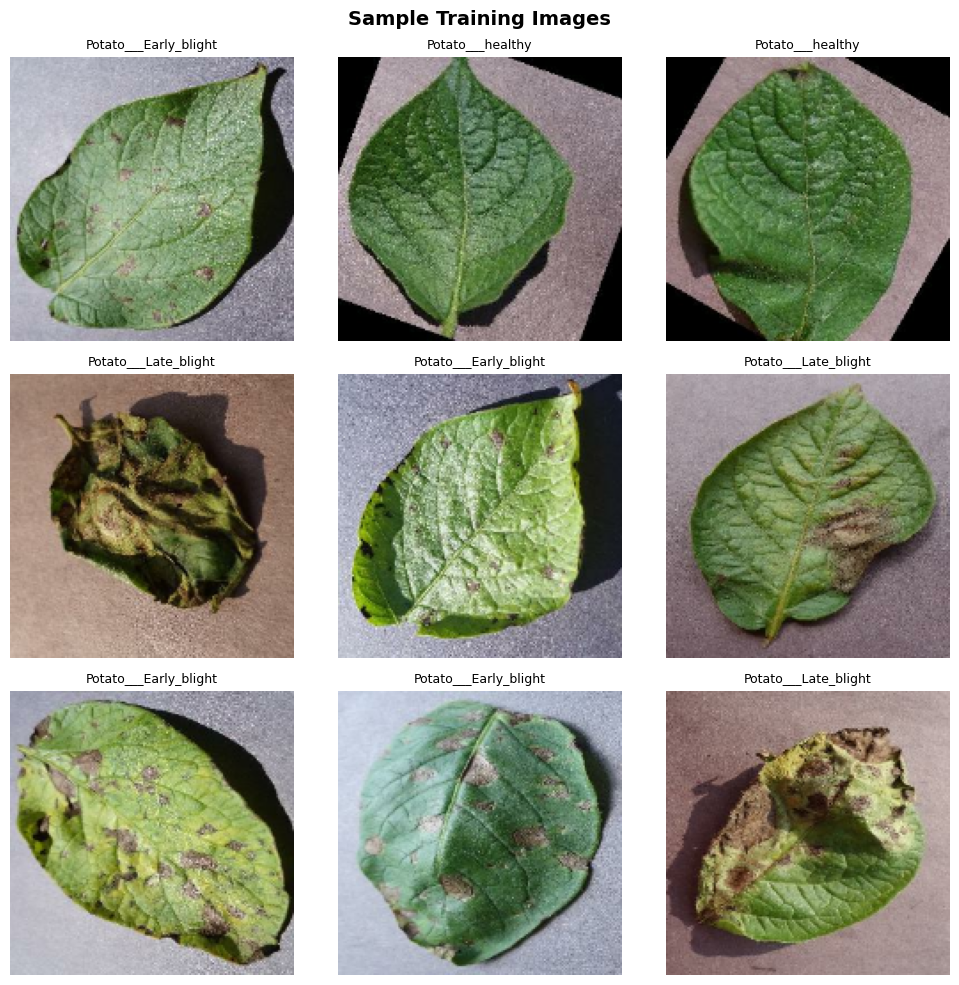

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 7 — Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# Apply augmentation ONLY to training data
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

print('✅ Data augmentation applied to training set.')


✅ Data augmentation applied to training set.


## Cell 8 — EfficientNet Preprocessing + Cache/Prefetch

In [8]:
# EfficientNet expects raw [0-255] pixels — it handles its own normalization internally
# DO NOT divide by 255 — that would double-scale and break predictions
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
)
validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
)
test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE
)

train_dataset      = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset       = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Verify shapes
for images, labels in train_dataset.take(1):
    print('Image batch shape:', images.shape)  # (32, 160, 160, 3)
    print('Label batch shape:', labels.shape)  # (32,)


Image batch shape: (32, 160, 160, 3)
Label batch shape: (32,)


## Cell 9 — Build Model (EfficientNetB4 + Custom Head)

In [9]:
IMG_SHAPE = IMG_SIZE + (3,)  # (160, 160, 3)

# Load pretrained EfficientNetB4 without top classification layer
base_model = tf.keras.applications.EfficientNetB4(
    input_shape = IMG_SHAPE,
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False  # Freeze all base layers initially

print('Base model output shape :', base_model.output_shape)
print('Total layers in base    :', len(base_model.layers))
print('Trainable variables     :', len(base_model.trainable_variables))


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Base model output shape : (None, 5, 5, 1792)
Total layers in base    : 475
Trainable variables     : 0


In [10]:
# Build full model
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer     = tf.keras.layers.Dense(len(class_names), activation='softmax')

inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = global_average_layer(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)
model.summary()
print('\nTrainable variables (should be 2 — Dense only):', len(model.trainable_variables))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         5,379 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,679,202 (67.44 MB)

 Trainable params: 5,379 (21.01 KB)

 Non-trainable params: 17,673,823 (67.42 MB)


Trainable variables (should be 2 — Dense only): 2


## Cell 10 — Compile & Phase 1 Training (Frozen Base)

In [11]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ['accuracy']
)

initial_epochs = 6

print('--- Initial evaluation before training ---')
loss0, acc0 = model.evaluate(validation_dataset, verbose=0)
print(f'Initial loss: {loss0:.4f}  |  Initial accuracy: {acc0:.4f}')

print('\n--- Phase 1: Training with frozen base ---')
history = model.fit(
    train_dataset,
    epochs          = initial_epochs,
    validation_data = validation_dataset
)


--- Initial evaluation before training ---
Initial loss: 1.1988  |  Initial accuracy: 0.3222

--- Phase 1: Training with frozen base ---
Epoch 1/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 123s 758ms/step - accuracy: 0.8310 - loss: 0.4857 - val_accuracy: 0.9243 - val_loss: 0.2539
Epoch 2/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 99s 689ms/step - accuracy: 0.9230 - loss: 0.2484 - val_accuracy: 0.9437 - val_loss: 0.1764
Epoch 3/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 132s 924ms/step - accuracy: 0.9399 - loss: 0.1912 - val_accuracy: 0.9577 - val_loss: 0.1430
Epoch 4/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.9507 - loss: 0.1641 - val_accuracy: 0.9595 - val_loss: 0.1230
Epoch 5/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9526 - loss: 0.1503 - val_accuracy: 0.9701 - val_loss: 0.1087
Epoch 6/6
143/143 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9605 - loss: 0.1297 - val_accuracy: 0.9648 - val_loss: 0.1004


## Cell 11 — Plot Phase 1 Results

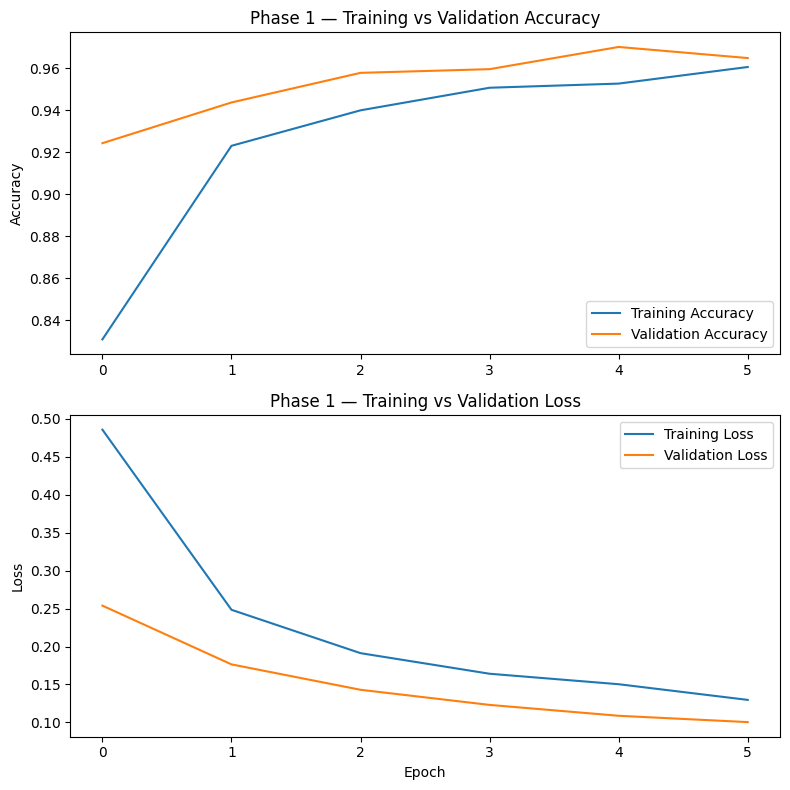

In [12]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc,     label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title('Phase 1 — Training vs Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss,     label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.title('Phase 1 — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()


## Cell 12 — Phase 2: Fine-Tuning (Unfreeze Top Layers)

In [13]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers before layer 100 — only train the top portion
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count   = sum(l.trainable for l in base_model.layers)
frozen_count      = len(base_model.layers) - trainable_count
print(f'Trainable layers : {trainable_count}')
print(f'Frozen layers    : {frozen_count}')

# Recompile with a much lower learning rate for fine-tuning
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ['accuracy']
)

fine_tune_epochs = 10
total_epochs     = initial_epochs + fine_tune_epochs

print(f'\n--- Phase 2: Fine-tuning from epoch {initial_epochs} to {total_epochs} ---')
history_fine = model.fit(
    train_dataset,
    epochs          = total_epochs,
    initial_epoch   = len(history.epoch),  # Continue from where Phase 1 stopped
    validation_data = validation_dataset
)


Trainable layers : 375
Frozen layers    : 100

--- Phase 2: Fine-tuning from epoch 6 to 16 ---
Epoch 7/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 1021s 6s/step - accuracy: 0.8187 - loss: 0.4595 - val_accuracy: 0.9366 - val_loss: 0.1577
Epoch 8/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.9281 - loss: 0.2096 - val_accuracy: 0.9437 - val_loss: 0.1373
Epoch 9/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 1757s 12s/step - accuracy: 0.9597 - loss: 0.1239 - val_accuracy: 0.9577 - val_loss: 0.1080
Epoch 10/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 876s 6s/step - accuracy: 0.9765 - loss: 0.0796 - val_accuracy: 0.9648 - val_loss: 0.0892
Epoch 11/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 576s 4s/step - accuracy: 0.9901 - loss: 0.0487 - val_accuracy: 0.9736 - val_loss: 0.0759
Epoch 12/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.9921 - loss: 0.0352 - val_accuracy: 0.9771 - val_loss: 0.0670
Epoch 13/16
143/143 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.9941 - loss: 0.0286 - val_accuracy: 0.9771 - val_loss: 0.

## Cell 13 — Plot Combined Training Curves

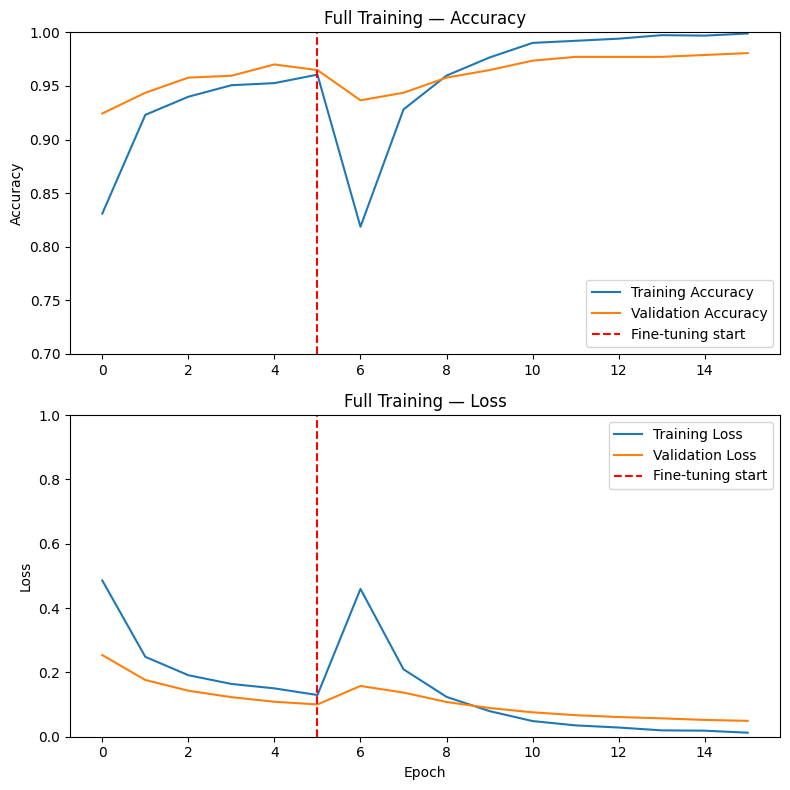

In [14]:
acc      += history_fine.history['accuracy']
val_acc  += history_fine.history['val_accuracy']
loss     += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(acc,     label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.7, 1])
plt.axvline(initial_epochs - 1, color='red', linestyle='--', label='Fine-tuning start')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title('Full Training — Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss,     label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.axvline(initial_epochs - 1, color='red', linestyle='--', label='Fine-tuning start')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.title('Full Training — Loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()


## Cell 14 — Evaluate on Test Set

In [15]:
print('--- Final Evaluation on Test Set ---')
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')


--- Final Evaluation on Test Set ---
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 952ms/step - accuracy: 0.9913 - loss: 0.0275

Test Loss     : 0.0275
Test Accuracy : 0.9913 (99.13%)


## Cell 15 — Visualise Predictions on Test Batch

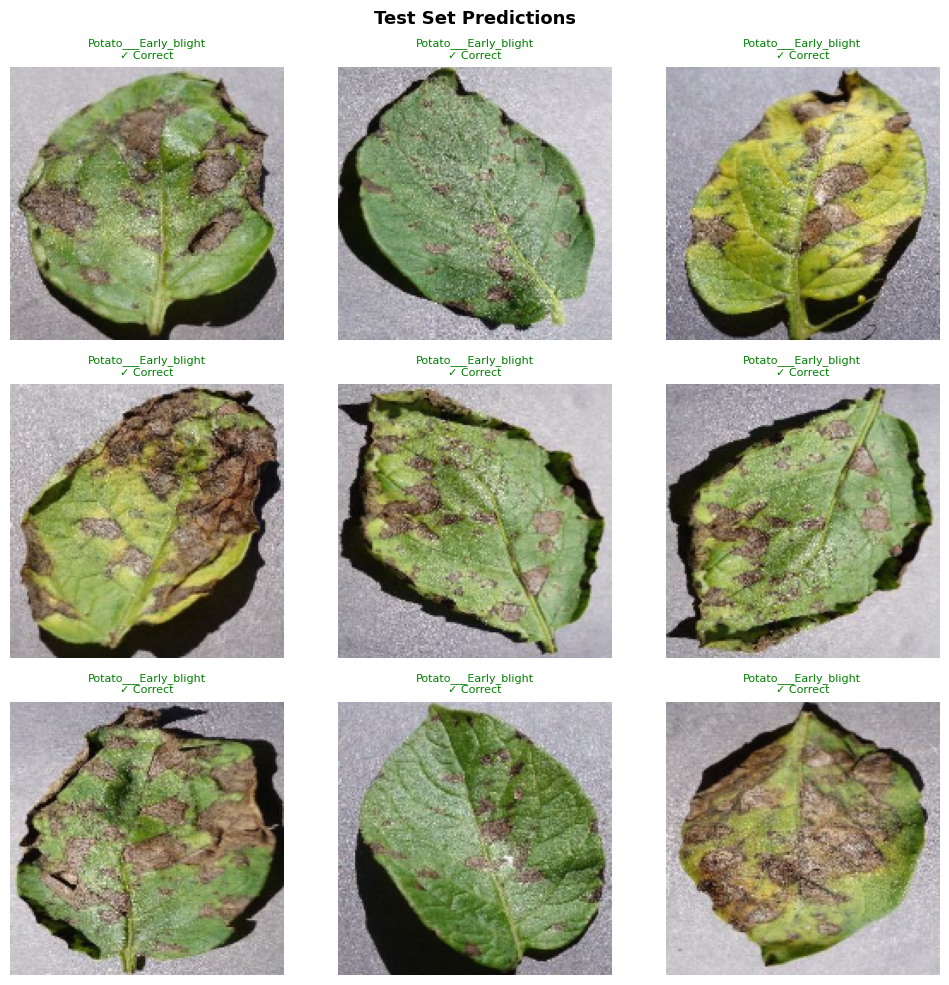

In [16]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()

predictions       = model.predict_on_batch(image_batch)
predicted_indices = tf.argmax(predictions, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Note: image_batch is preprocessed (EfficientNet scaled), cast carefully for display
    display_img = image_batch[i].astype('float32')
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    plt.imshow(display_img)
    correct = predicted_indices[i] == label_batch[i]
    plt.title(
        f"{class_names[predicted_indices[i]]}\n{'✓ Correct' if correct else '✗ Wrong'}",
        color='green' if correct else 'red',
        fontsize=8
    )
    plt.axis('off')
plt.suptitle('Test Set Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 16 — Save Model (So You Never Have to Retrain)

In [17]:
model.save(MODEL_PATH)
print(f'✅ Model saved to: {MODEL_PATH}')
print('You can now load it anytime with:')
print(f'  model = tf.keras.models.load_model(r"{MODEL_PATH}")')


✅ Model saved to: C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor\plant_disease_model.keras
You can now load it anytime with:
  model = tf.keras.models.load_model(r"C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor\plant_disease_model.keras")


## Cell 17 — Load & Test Saved Model (Run this instead of retraining)

In [18]:
import tensorflow as tf
import os

BASE_DIR   = r'C:\Users\Omkar\OneDrive\Desktop\Crop_Disease_Predictor'
MODEL_PATH = os.path.join(BASE_DIR, 'plant_disease_model.keras')

model = tf.keras.models.load_model(MODEL_PATH)
print('✅ Model loaded successfully!')
model.summary()


✅ Model loaded successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         5,379 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,613,674 (200.71 MB)

 Trainable params: 17,467,235 (66.63 MB)

 Non-trainable params: 211,967 (828.00 KB)

 Optimizer params: 34,934,472 (133.26 MB)

## Cell 18 — Predict a Single Image

In [1]:
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE    = (160, 160)
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

def predict_leaf(image_path):
    # Load and resize
    img         = Image.open(image_path).convert('RGB')
    img_resized = img.resize(IMG_SIZE)

    # Preprocess exactly like training — raw [0-255] → preprocess_input
    # DO NOT divide by 255 — EfficientNet does its own scaling internally
    img_array = tf.keras.utils.img_to_array(img_resized)   # [0, 255]
    img_array = tf.expand_dims(img_array, axis=0)           # (1,160,160,3)
    img_array = preprocess_input(img_array)                 # EfficientNet scaling

    # Predict
    predictions     = model.predict(img_array, verbose=0)
    predicted_class = class_names[int(tf.argmax(predictions[0]))]
    confidence      = float(100 * tf.reduce_max(predictions[0]))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title('Input Leaf', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    scores = predictions[0] * 100
    colors = ['tomato', 'orange', 'mediumseagreen']
    bars   = axes[1].barh(class_names, scores, color=colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Class Probabilities', fontsize=12, fontweight='bold')
    axes[1].set_xlim([0, 100])
    for bar, s in zip(bars, scores):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                     f'{s:.1f}%', va='center', fontweight='bold')

    color_map = {
        'Potato___Early_blight': 'orange',
        'Potato___Late_blight' : 'red',
        'Potato___healthy'     : 'green'
    }
    plt.suptitle(f'Prediction: {predicted_class}  |  Confidence: {confidence:.1f}%',
                 fontsize=13, fontweight='bold', color=color_map[predicted_class])
    plt.tight_layout()
    plt.show()

    print(f'\nPredicted : {predicted_class}')
    print(f'Confidence: {confidence:.2f}%')

# ── Change path to your image ──────────────────────────────────
predict_leaf(r'C:\Users\Omkar\Desktop\Crop_Disease_Predictor\test\Potato___healthy\0a1b2c3d4e5f6g7h8i9j.jpg')


KeyboardInterrupt: 